In [1]:
!pip install kaggle --quiet

In [2]:
from google.colab import files

# This will prompt you to select the kaggle.json file from your PC
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
# 1. Create the hidden .kaggle directory
!mkdir -p ~/.kaggle

# 2. Copy the uploaded kaggle.json file into that new directory
!cp kaggle.json ~/.kaggle/

# 3. Change permissions so only you/this notebook can read the secret key
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API successfully set up!")

Kaggle API successfully set up!


In [4]:
# Download the dataset using its Kaggle API command
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip the downloaded file quietly (-q) into a folder named 'chest_xray'
!unzip -q chest-xray-pneumonia.zip -d chest_xray

print("Dataset downloaded and extracted!")

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:58<00:00, 42.2MB/s]

Dataset downloaded and extracted!


In [5]:
import os

# List the contents of the newly extracted folder
print(os.listdir('./chest_xray'))

['chest_xray']


In [6]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

# The standard path where the Kaggle zip extracts the images
train_dir = './chest_xray/chest_xray/train'
val_dir = './chest_xray/chest_xray/val'

# Transformations for ResNet-50
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load data into PyTorch
train_data = datasets.ImageFolder(root=train_dir, transform=train_transforms)
val_data = datasets.ImageFolder(root=val_dir, transform=val_transforms)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=32, shuffle=False)

print(f"Data ready! Loaded {len(train_data)} training images.")

Data ready! Loaded 5216 training images.


### Model Initialization & Imbalance Handling
Loading the pre-trained ResNet-50 and modifying the final layer to output 2 classes.
To satisfy the Phase 2 requirements, we introduce a tunable Dropout layer and configure a weighted `CrossEntropyLoss` to handle the 3:1 (Pneumonia:Normal) class imbalance.

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load ResNet-50
weights = models.ResNet50_Weights.IMAGENET1K_V2
model = models.resnet50(weights=weights)

# Modify the final layer and inject Dropout for optimization
num_ftrs = model.fc.in_features
dropout_rate = 0.5  # You can tune this later!
model.fc = nn.Sequential(
    nn.Dropout(p=dropout_rate),
    nn.Linear(num_ftrs, 2) # 2 classes: Normal and Pneumonia
)
model = model.to(device)

# Apply Weighted Loss (3:1 ratio for Pneumonia to Normal)
class_weights = torch.tensor([3.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Set Optimizer and Learning Rate
learning_rate = 0.001 # You can tune this later too!
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


### Model Training & Metric Tracking
Executing the training loop. We will track the loss and accuracy per epoch to generate the required performance curves.

In [10]:
num_epochs = 10
# Add this right before your epoch loop starts to confirm the data is there
print(f"Total training batches per epoch: {len(train_loader)}")

# Storage for your curve plots
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    # Notice the added 'enumerate' here!
    for i, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()


        if i % 10 == 0:  # Print an update every 10 batches
            print(f"  -> Epoch {epoch+1} | Processing batch {i}/{len(train_loader)}")


    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = correct / total
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)

    # Validation Phase
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    epoch_val_acc = val_correct / val_total
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f}, Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f}, Acc: {epoch_val_acc:.4f}")


Total training batches per epoch: 163
  -> Epoch 1 | Processing batch 0/163
  -> Epoch 1 | Processing batch 10/163
  -> Epoch 1 | Processing batch 20/163
  -> Epoch 1 | Processing batch 30/163
  -> Epoch 1 | Processing batch 40/163
  -> Epoch 1 | Processing batch 50/163
  -> Epoch 1 | Processing batch 60/163
  -> Epoch 1 | Processing batch 70/163
  -> Epoch 1 | Processing batch 80/163
  -> Epoch 1 | Processing batch 90/163
  -> Epoch 1 | Processing batch 100/163
  -> Epoch 1 | Processing batch 110/163
  -> Epoch 1 | Processing batch 120/163
  -> Epoch 1 | Processing batch 130/163
  -> Epoch 1 | Processing batch 140/163
  -> Epoch 1 | Processing batch 150/163
  -> Epoch 1 | Processing batch 160/163
Epoch 1/10 | Train Loss: 0.1254, Acc: 0.9509 | Val Loss: 0.3370, Acc: 0.9375
  -> Epoch 2 | Processing batch 0/163
  -> Epoch 2 | Processing batch 10/163
  -> Epoch 2 | Processing batch 20/163
  -> Epoch 2 | Processing batch 30/163
  -> Epoch 2 | Processing batch 40/163
  -> Epoch 2 | Process

### Deliverable: Loss & Accuracy Curves

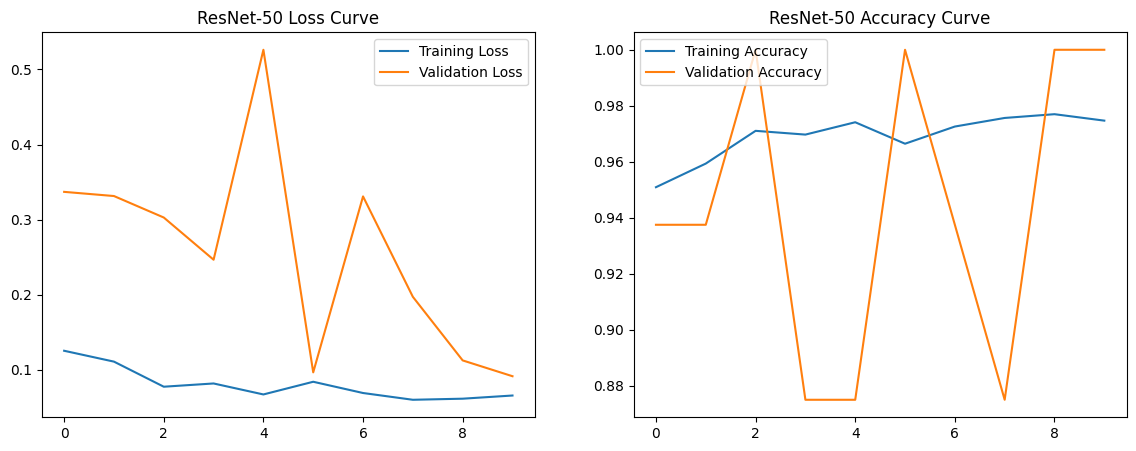

Model saved as 'resnet50_optimized.pth'


In [11]:
# Plotting Loss and Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('ResNet-50 Loss Curve')
ax1.legend()

ax2.plot(train_accuracies, label='Training Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('ResNet-50 Accuracy Curve')
ax2.legend()

plt.show()

# Save the model for the final integration
torch.save(model.state_dict(), 'resnet50_optimized.pth')
print("Model saved as 'resnet50_optimized.pth'")

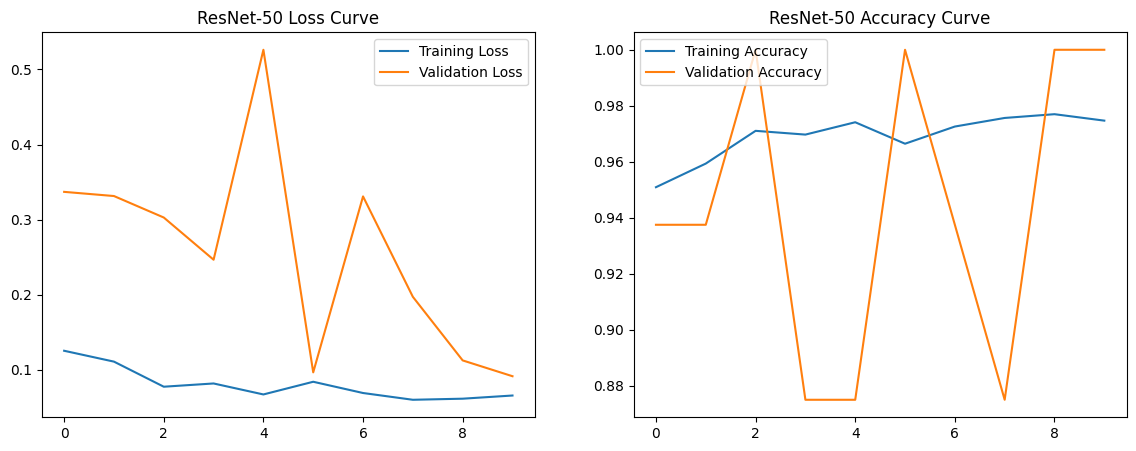

Model saved as 'resnet50_optimized.pth'


In [12]:
# Plotting Loss and Accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Training Loss')
ax1.plot(val_losses, label='Validation Loss')
ax1.set_title('ResNet-50 Loss Curve')
ax1.legend()

ax2.plot(train_accuracies, label='Training Accuracy')
ax2.plot(val_accuracies, label='Validation Accuracy')
ax2.set_title('ResNet-50 Accuracy Curve')
ax2.legend()

plt.show()

# Save the model for the final integration
torch.save(model.state_dict(), 'resnet50_optimized.pth')
print("Model saved as 'resnet50_optimized.pth'")

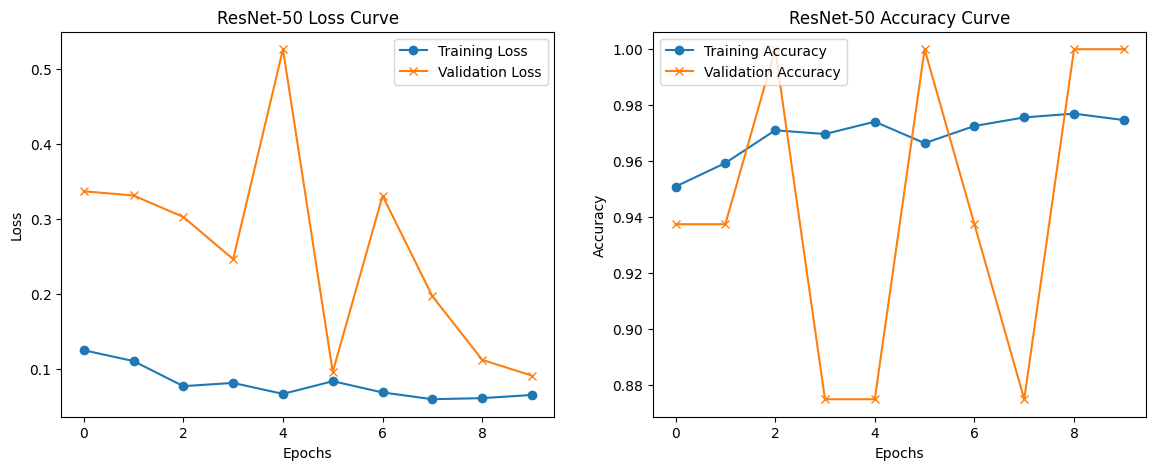


--- Running Final Evaluation on Test Set ---
              precision    recall  f1-score   support

      NORMAL       0.93      0.79      0.85       234
   PNEUMONIA       0.88      0.96      0.92       390

    accuracy                           0.90       624
   macro avg       0.90      0.88      0.89       624
weighted avg       0.90      0.90      0.90       624

Model saved as 'resnet50_optimized.pth'


In [13]:
import os
from torchvision import datasets, transforms
import torch
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Define test directory and transformations (using validation transforms for consistency)
test_dir = './chest_xray/chest_xray/test'

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load test data
test_data = datasets.ImageFolder(root=test_dir, transform=test_transforms)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=32, shuffle=False)

# 1. Plot the Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(train_losses, label='Training Loss', marker='o')
ax1.plot(val_losses, label='Validation Loss', marker='x')
ax1.set_title('ResNet-50 Loss Curve')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(train_accuracies, label='Training Accuracy', marker='o')
ax2.plot(val_accuracies, label='Validation Accuracy', marker='x')
ax2.set_title('ResNet-50 Accuracy Curve')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.show()

# 2. Final Test Set Evaluation
print("\n--- Running Final Evaluation on Test Set ---")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Generate Classification Report (Precision, Recall, F1)
print(classification_report(all_labels, all_preds, target_names=train_data.classes))

# Save the final model weights
torch.save(model.state_dict(), 'resnet50_optimized.pth')
print("Model saved as 'resnet50_optimized.pth'")


Evaluating the model on the test dataset...
------------------------------
Final Accuracy Score: 89.74%
------------------------------


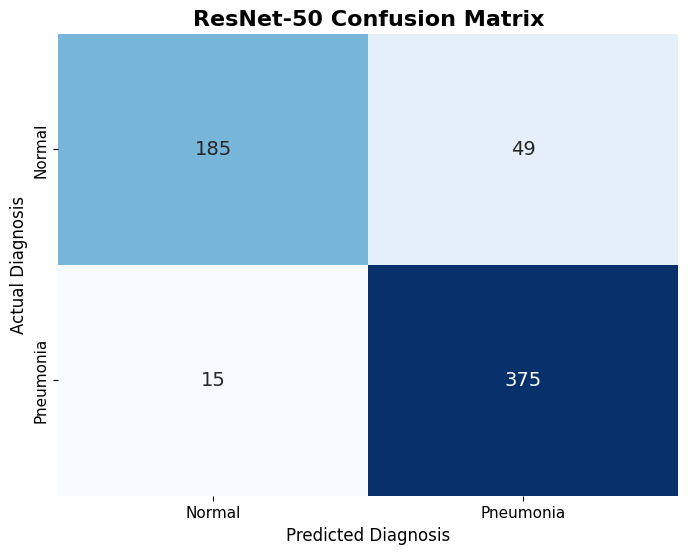

In [14]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Set model to evaluation mode
model.eval()

# Lists to store the actual and predicted labels
all_preds = []
all_actuals = []

print("Evaluating the model on the test dataset...")

# 2. Run the test data through the model without tracking gradients
with torch.no_grad():
    # Assuming your test data loader is named 'test_loader'
    # (If you only have val_loader loaded right now, you can swap it in here)
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

        # Move data back to CPU and append to our lists
        all_preds.extend(predicted.cpu().numpy())
        all_actuals.extend(labels.cpu().numpy())

# 3. Calculate and Print Final Accuracy
# This mirrors the final score output you were looking for
final_accuracy = accuracy_score(all_actuals, all_preds)
print("-" * 30)
print(f"Final Accuracy Score: {final_accuracy * 100:.2f}%")
print("-" * 30)

# 4. Generate the Confusion Matrix
cm = confusion_matrix(all_actuals, all_preds)

# 5. Visualize the Matrix using Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'],
            annot_kws={"size": 14}) # Makes the numbers larger and easier to read

# Add formatting and labels
plt.title('ResNet-50 Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

------------------------------
Final Accuracy Score on Test Set: 89.74%
------------------------------
Specificity (True Negative Rate for 'Normal' class): 79.06%
------------------------------


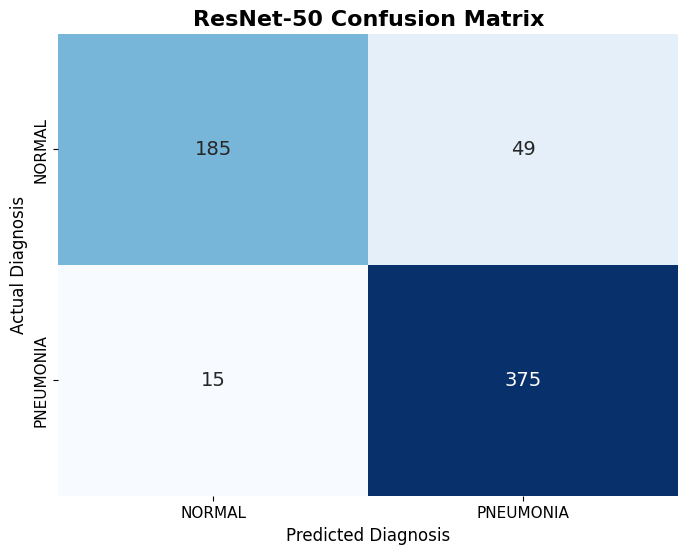

In [15]:
import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate and Print Final Accuracy Score
# This will output the single, overall score matching the 'Final Score' format.
final_accuracy = sklearn.metrics.accuracy_score(all_labels, all_preds)
print("-" * 30)
print(f"Final Accuracy Score on Test Set: {final_accuracy * 100:.2f}%")
print("-" * 30)

# 2. Generate the Confusion Matrix
# We utilize 'cm' to perform the Specificity calculation later if needed for the comparative analysis.
cm = sklearn.metrics.confusion_matrix(all_labels, all_preds)

# 3. Specificity Calculation for the Minority 'NORMAL' Class
# Medical datasets often require Specificity (True Negative Rate) for robust evaluation.
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"Specificity (True Negative Rate for 'Normal' class): {specificity * 100:.2f}%")
print("-" * 30)

# 4. Visualize the Confusion Matrix using a Seaborn Heatmap
plt.figure(figsize=(8, 6))

# Map the class labels (0, 1) to their proper names from your dataset
class_names = train_data.classes

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14}) # Increase annotation size for readability

# Formatting to match the provided reference figure
plt.title('ResNet-50 Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Diagnosis', fontsize=12)
plt.xlabel('Predicted Diagnosis', fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()